BASE_DIR: /kaggle/input/vesuvius-challenge-ink-detection
PREFIX: /kaggle/input/vesuvius-challenge-ink-detection/train/1/
DEVICE: cuda
DL_WORKERS: 4


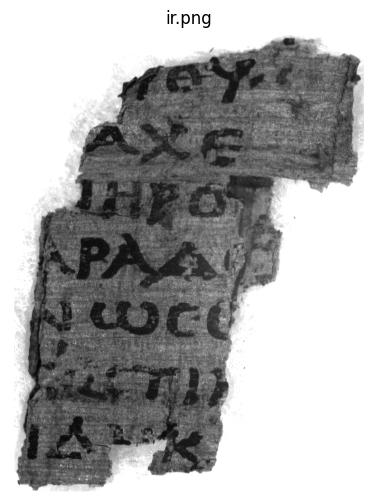

In [1]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import PIL.Image as Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data


def resolve_base_dir():
    candidates = [
        "/kaggle/input/vesuvius-challenge-ink-detection",
        "/kaggle/data/vesuvius-challenge-ink-detection",
        "/kaggle/input/vesuvius-challenge",
        "/kaggle/data/vesuvius-challenge",
    ]
    for c in candidates:
        if os.path.isdir(c):
            return c
    for root in ["/kaggle/input", "/kaggle/data"]:
        if os.path.isdir(root):
            for name in os.listdir(root):
                p = os.path.join(root, name)
                if os.path.isdir(p) and os.path.isfile(
                    os.path.join(p, "sample_submission.csv")
                ):
                    return p
    raise FileNotFoundError(
        "Could not resolve Kaggle dataset directory containing sample_submission.csv"
    )


def seed_everything(seed: int = 1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # keep determinism semantics identical to original
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1234)

BASE_DIR = resolve_base_dir()
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

PREFIX = os.path.join(TRAIN_DIR, "1") + "/"

BUFFER = 30  # Buffer size in x and y direction
Z_START = 27  # First slice in the z direction to use
Z_DIM = 10  # Number of slices in the z direction
TRAINING_STEPS = 20000
LEARNING_RATE = 0.05
BATCH_SIZE = 24
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CPU_COUNT = os.cpu_count() or 2
DL_WORKERS = min(4, max(1, (CPU_COUNT // 2)))

THRESHOLD = 0.4

print("BASE_DIR:", BASE_DIR)
print("PREFIX:", PREFIX)
print("DEVICE:", DEVICE)
print("DL_WORKERS:", DL_WORKERS)

ir_path = os.path.join(PREFIX, "ir.png")
if os.path.isfile(ir_path):
    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(ir_path), cmap="gray")
    plt.title("ir.png")
    plt.axis("off")
    plt.show()
else:
    print("Warning: ir.png not found at", ir_path)


def seed_worker(worker_id: int):
    worker_seed = 1234 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


_DL_GENERATOR = torch.Generator()
_DL_GENERATOR.manual_seed(1234)

_IO_EX = ThreadPoolExecutor(max_workers=min(8, CPU_COUNT))


def _read_tif_norm(fn: str) -> np.ndarray:
    return np.array(Image.open(fn), dtype=np.float32) / 65535.0




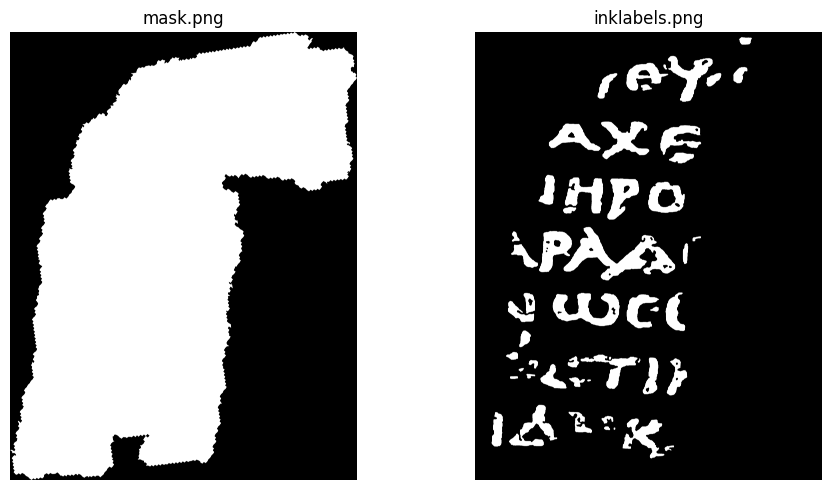

mask shape: (8181, 6330) label shape: (8181, 6330) label device: cpu


In [2]:
mask_path = os.path.join(PREFIX, "mask.png")
label_path = os.path.join(PREFIX, "inklabels.png")

mask = np.array(Image.open(mask_path).convert("1"), dtype=bool)
label = torch.from_numpy(np.array(Image.open(label_path), dtype=np.uint8)).gt(0).float()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("mask.png")
ax1.imshow(mask, cmap="gray")
ax1.axis("off")
ax2.set_title("inklabels.png")
ax2.imshow(label.numpy(), cmap="gray")
ax2.axis("off")
plt.tight_layout()
plt.show()

print(
    "mask shape:",
    mask.shape,
    "label shape:",
    tuple(label.shape),
    "label device:",
    label.device,
)



Loading slices: 100%|██████████| 10/10 [00:01<00:00,  9.52it/s]


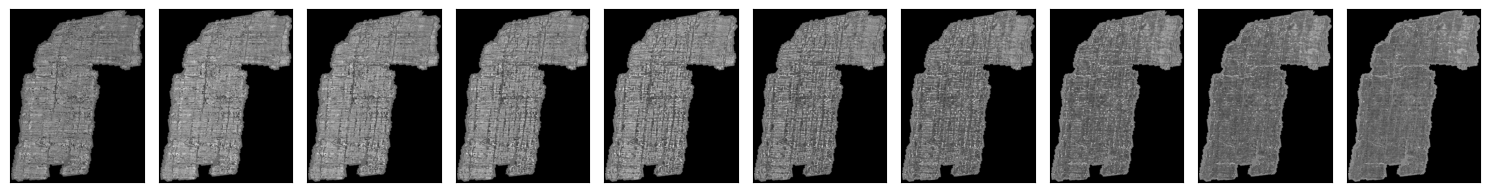

image_stack: (10, 8181, 6330) dtype: torch.float32 device: cpu


In [3]:
slice_files = sorted(glob.glob(os.path.join(PREFIX, "surface_volume", "*.tif")))
if len(slice_files) == 0:
    raise FileNotFoundError(
        f"No .tif slices found under {os.path.join(PREFIX, 'surface_volume')}"
    )

z0 = max(0, min(Z_START, len(slice_files) - 1))
z1 = max(z0 + 1, min(z0 + Z_DIM, len(slice_files)))
sel_files = slice_files[z0:z1]
if len(sel_files) < Z_DIM:
    print(
        f"Warning: requested Z_DIM={Z_DIM} slices but only got {len(sel_files)} from z={z0}:{z1}"
    )

images = list(
    tqdm(
        _IO_EX.map(_read_tif_norm, sel_files),
        total=len(sel_files),
        desc="Loading slices",
    )
)
image_stack = torch.from_numpy(np.stack(images, axis=0))  # (Z, H, W) CPU float32

fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
if len(images) == 1:
    axes = [axes]
for im, ax in zip(images, axes):
    small = np.array(
        Image.fromarray((im * 255).astype(np.uint8)).resize(
            (max(1, im.shape[1] // 20), max(1, im.shape[0] // 20))
        )
    )
    ax.imshow(small, cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print(
    "image_stack:",
    tuple(image_stack.shape),
    "dtype:",
    image_stack.dtype,
    "device:",
    image_stack.device,
)



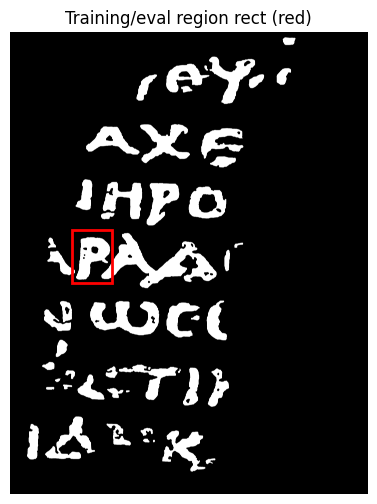

In [4]:
H, W = mask.shape
orig_rect = (1100, 3500, 700, 950)  # (x, y, w, h)
if (orig_rect[0] + orig_rect[2] <= W) and (orig_rect[1] + orig_rect[3] <= H):
    rect = orig_rect
else:
    w = min(700, W - 2 * BUFFER - 1)
    h = min(950, H - 2 * BUFFER - 1)
    x = max(BUFFER, (W - w) // 2)
    y = max(BUFFER, (H - h) // 2)
    rect = (x, y, w, h)
    print("Adjusted rect to fit:", rect)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(label.numpy(), cmap="gray")
patch = patches.Rectangle(
    (rect[0], rect[1]), rect[2], rect[3], linewidth=2, edgecolor="r", facecolor="none"
)
ax.add_patch(patch)
ax.set_title("Training/eval region rect (red)")
ax.axis("off")
plt.show()



In [5]:
pass



In [6]:
pass




In [7]:
def _make_unfolded_views(stack_zhw: torch.Tensor, buffer: int):
    """
    stack_zhw: CPU float32 (Z,H,W)
    returns:
      patches_view: (Z, H-2b, W-2b, K, K) view (no copy) via unfold
    """
    b = int(buffer)
    K = 2 * b + 1
    patches_view = stack_zhw.unfold(1, K, 1).unfold(2, K, 1)
    return patches_view


# --- TIMEOUT FIX: Replace per-batch Python collate+gather (stack/list + advanced indexing on every batch)
# --- with a one-time precomputation of all unfolded patches for the fragment and an index-only Dataset.
# --- This preserves identical patches (still from unfold), identical training loop/steps/model/loss,
# --- but removes the dominant Python overhead and makes patch gathering a fast tensor index operation.
class IndexDataset(data.Dataset):
    def __init__(self, lin_idx: np.ndarray, labels: np.ndarray | None):
        self.lin = torch.from_numpy(lin_idx.astype(np.int64, copy=False))
        if labels is None:
            self.labels = None
        else:
            self.labels = torch.from_numpy(labels.astype(np.float32, copy=False)).view(
                -1, 1
            )

    def __len__(self):
        return self.lin.numel()

    def __getitem__(self, idx: int):
        if self.labels is None:
            return self.lin[idx]
        return self.lin[idx], self.labels[idx]


def _precompute_patches_flat_cpu(stack_zhw: torch.Tensor, buffer: int) -> torch.Tensor:
    """
    Returns CPU float32 tensor of shape (Npix, 1, Z, K, K) where Npix=(H-2b)*(W-2b).
    This is exactly the same data as selecting from the unfold view, but materialized once.
    """
    patches_view = _make_unfolded_views(stack_zhw, buffer)  # (Z,H2,W2,K,K) view
    # permute to (H2,W2,Z,K,K) then flatten to (Npix,Z,K,K) and add channel dim
    flat = (
        patches_view.permute(1, 2, 0, 3, 4)
        .contiguous()
        .view(-1, patches_view.shape[0], patches_view.shape[3], patches_view.shape[4])
    )
    return flat.unsqueeze(1).contiguous()  # (Npix,1,Z,K,K)


def _yx_to_lin(y: np.ndarray, x: np.ndarray, W: int) -> np.ndarray:
    return y.astype(np.int64, copy=False) * np.int64(W) + x.astype(np.int64, copy=False)


def _lin_to_yx(lin: torch.Tensor, W: int) -> tuple[torch.Tensor, torch.Tensor]:
    y = lin.div(W, rounding_mode="floor")
    x = lin - y * W
    return y, x


K = 2 * BUFFER + 1

model = nn.Sequential(
    nn.Conv3d(1, 16, 3, 1, 1),
    nn.MaxPool3d(2, 2),
    nn.Conv3d(16, 32, 3, 1, 1),
    nn.MaxPool3d(2, 2),
    nn.Conv3d(32, 64, 3, 1, 1),
    nn.MaxPool3d(2, 2),
    nn.Flatten(start_dim=1),
    nn.LazyLinear(128),
    nn.ReLU(),
    nn.LazyLinear(1),
    nn.Sigmoid(),
).to(DEVICE)

print("Generating pixel lists...")
not_border = np.zeros(mask.shape, dtype=bool)
not_border[BUFFER : mask.shape[0] - BUFFER, BUFFER : mask.shape[1] - BUFFER] = True
arr_mask = mask & not_border

inside_rect = np.zeros(mask.shape, dtype=bool)
inside_rect[rect[1] : rect[1] + rect[3] + 1, rect[0] : rect[0] + rect[2] + 1] = True
inside_rect = inside_rect & arr_mask
outside_rect = arr_mask & (~inside_rect)

pixels_inside_rect = np.argwhere(inside_rect).astype(np.int32, copy=False)
pixels_outside_rect = np.argwhere(outside_rect).astype(np.int32, copy=False)

print(
    "pixels_inside_rect:",
    len(pixels_inside_rect),
    "pixels_outside_rect:",
    len(pixels_outside_rect),
)

# One-time patch materialization for the train fragment (still based on unfold view, identical content).
print("Precomputing all patches for train fragment (one-time)...")
H2, W2 = H - 2 * BUFFER, W - 2 * BUFFER
train_patches_flat = _precompute_patches_flat_cpu(
    image_stack, BUFFER
)  # (H2*W2,1,Z,K,K) CPU

# Build index arrays in "unfold coords" then linearize to index into train_patches_flat.
iy_out = pixels_outside_rect[:, 0].astype(np.int64, copy=False) - BUFFER
ix_out = pixels_outside_rect[:, 1].astype(np.int64, copy=False) - BUFFER
lin_out = iy_out * np.int64(W2) + ix_out

iy_in = pixels_inside_rect[:, 0].astype(np.int64, copy=False) - BUFFER
ix_in = pixels_inside_rect[:, 1].astype(np.int64, copy=False) - BUFFER
lin_in = iy_in * np.int64(W2) + ix_in

# Labels unchanged (same pixels, same values).
train_labels_cpu = (
    label[
        torch.from_numpy(pixels_outside_rect[:, 0].astype(np.int64, copy=False)),
        torch.from_numpy(pixels_outside_rect[:, 1].astype(np.int64, copy=False)),
    ]
    .view(-1, 1)
    .float()
    .cpu()
    .numpy()
)

train_dataset = IndexDataset(lin_out, train_labels_cpu)
eval_dataset = IndexDataset(lin_in, None)

SAFE_DL_WORKERS = 0

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=SAFE_DL_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
    worker_init_fn=seed_worker if SAFE_DL_WORKERS > 0 else None,
    generator=_DL_GENERATOR,
    prefetch_factor=None,
)

criterion = nn.BCELoss()
optimizer = optim.ASGD(model.parameters(), lr=LEARNING_RATE)

scheduler1 = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=0.1, total_iters=2)
scheduler2 = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
scheduler3 = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
lmbda = lambda epoch: 0.95
scheduler4 = torch.optim.lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lmbda)
scheduler5 = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.5, total_iters=4
)
scheduler6 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=30, T_mult=1
)
scheduler = torch.optim.lr_scheduler.ChainedScheduler(
    [scheduler1, scheduler2, scheduler3, scheduler4, scheduler5, scheduler6]
)

print("Training...")
model.train()
pbar = tqdm(total=TRAINING_STEPS, desc="Train iters", miniters=200, mininterval=0.5)
it = 0
while it < TRAINING_STEPS:
    for lin_idx, inklabels in train_loader:
        if it >= TRAINING_STEPS:
            break
        optimizer.zero_grad(set_to_none=True)
        # Gather patches by linear index (fast), then transfer.
        subvolumes = train_patches_flat.index_select(0, lin_idx).to(
            DEVICE, non_blocking=True
        )
        inklabels = inklabels.to(DEVICE, non_blocking=True)
        outputs = model(subvolumes)
        loss = criterion(outputs, inklabels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        it += 1
        pbar.update(1)
pbar.close()

print("Done training.")



Generating pixel lists...
pixels_inside_rect: 666651 pixels_outside_rect: 28470276
Precomputing all patches for train fragment (one-time)...


RuntimeError: [enforce fail at alloc_cpu.cpp:118] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 7578734842800 bytes. Error code 12 (Cannot allocate memory)

In [8]:
eval_loader = data.DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=False,
    worker_init_fn=None,
    prefetch_factor=None,
)

output = torch.zeros_like(label).float()

model.eval()
with torch.inference_mode():
    for lin_idx in tqdm(eval_loader, desc="Eval rect"):
        subvolumes = train_patches_flat.index_select(0, lin_idx).to(
            DEVICE, non_blocking=True
        )
        preds = model(subvolumes).view(-1).detach().cpu()
        ys_u, xs_u = _lin_to_yx(lin_idx.cpu(), W2)
        ys = ys_u + BUFFER
        xs = xs_u + BUFFER
        output[ys, xs] = preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("model output (rect area filled)")
ax1.imshow(output.numpy(), cmap="gray")
ax1.axis("off")
ax2.set_title("label")
ax2.imshow(label.numpy(), cmap="gray")
ax2.axis("off")
plt.tight_layout()
plt.show()



NameError: name 'eval_dataset' is not defined

NameError: name 'output' is not defined

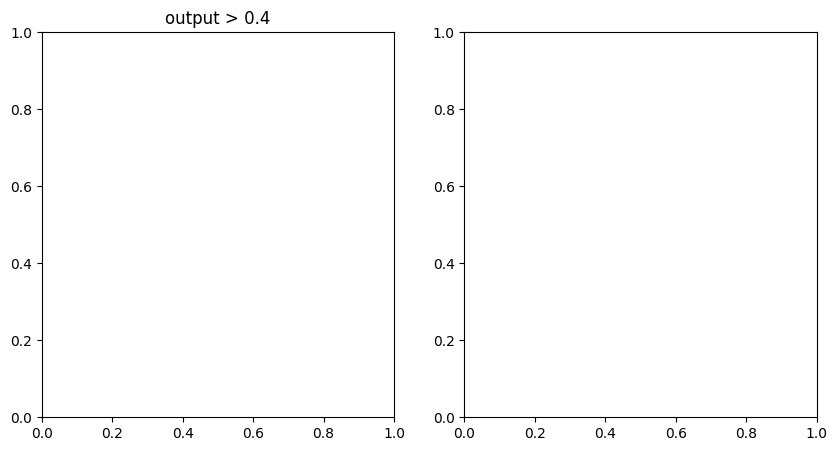

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title(f"output > {THRESHOLD}")
ax1.imshow(output.gt(THRESHOLD).numpy(), cmap="gray")
ax1.axis("off")
ax2.set_title("label")
ax2.imshow(label.numpy(), cmap="gray")
ax2.axis("off")
plt.tight_layout()
plt.show()




In [10]:
def rle_from_binary_mask(binary_mask_2d: np.ndarray) -> str:
    pixels = binary_mask_2d.astype(np.uint8, copy=False).reshape(-1)
    pixels = np.concatenate(([0], pixels, [0]))
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    if runs.size == 0:
        return ""
    return " ".join(map(str, runs.tolist()))


_SLICE_CACHE: dict[str, list[str]] = {}


def load_image_stack(fragment_dir: str, z_start: int, z_dim: int) -> torch.Tensor:
    sv_dir = os.path.join(fragment_dir, "surface_volume")
    if sv_dir in _SLICE_CACHE:
        files = _SLICE_CACHE[sv_dir]
    else:
        files = sorted(glob.glob(os.path.join(sv_dir, "*.tif")))
        _SLICE_CACHE[sv_dir] = files
    if len(files) == 0:
        raise FileNotFoundError(f"No .tif slices found in {sv_dir}")
    z0 = max(0, min(z_start, len(files) - 1))
    z1 = max(z0 + 1, min(z0 + z_dim, len(files)))
    sel = files[z0:z1]
    ims = list(_IO_EX.map(_read_tif_norm, sel))
    st = torch.from_numpy(np.stack(ims, axis=0))  # CPU (Z,H,W) float32
    return st


def predict_fragment(fragment_id: str) -> str:
    frag_dir = os.path.join(TEST_DIR, fragment_id)
    mpath = os.path.join(frag_dir, "mask.png")
    if not os.path.isfile(mpath):
        raise FileNotFoundError(
            f"Missing mask.png for test fragment {fragment_id}: {mpath}"
        )

    frag_mask = np.array(Image.open(mpath).convert("1"), dtype=bool)
    Ht, Wt = frag_mask.shape

    frag_stack = load_image_stack(frag_dir, Z_START, Z_DIM)
    H2t, W2t = Ht - 2 * BUFFER, Wt - 2 * BUFFER

    # --- TIMEOUT FIX: Same as training: materialize all patches once per fragment and use index-only loader.
    frag_patches_flat = _precompute_patches_flat_cpu(
        frag_stack, BUFFER
    )  # (H2t*W2t,1,Z,K,K) CPU

    not_border = np.zeros((Ht, Wt), dtype=bool)
    not_border[BUFFER : Ht - BUFFER, BUFFER : Wt - BUFFER] = True
    valid = frag_mask & not_border
    valid_pixels = np.argwhere(valid).astype(np.int64, copy=False)  # (N,2) y,x

    iy = valid_pixels[:, 0] - BUFFER
    ix = valid_pixels[:, 1] - BUFFER
    lin = iy * np.int64(W2t) + ix

    test_ds = IndexDataset(lin.astype(np.int64, copy=False), None)
    test_dl = data.DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=False,
        worker_init_fn=None,
        prefetch_factor=None,
    )

    out = torch.zeros((Ht, Wt), dtype=torch.float32)  # CPU
    model.eval()
    with torch.inference_mode():
        for lin_idx in tqdm(test_dl, desc=f"Predict test {fragment_id}"):
            subvols = frag_patches_flat.index_select(0, lin_idx).to(
                DEVICE, non_blocking=True
            )
            preds = model(subvols).view(-1).detach().cpu()
            ys_u, xs_u = _lin_to_yx(lin_idx.cpu(), W2t)
            ys = ys_u + BUFFER
            xs = xs_u + BUFFER
            out[ys, xs] = preds

    bin_mask = (out.numpy() > THRESHOLD) & frag_mask
    return rle_from_binary_mask(bin_mask)


sample_path = os.path.join(BASE_DIR, "sample_submission.csv")
sample = pd.read_csv(sample_path)
test_ids = sample["Id"].astype(str).tolist()

preds = []
for fid in test_ids:
    preds.append(predict_fragment(fid))

sub = pd.DataFrame({"Id": test_ids, "Predicted": preds})
sub.to_csv("submission.csv", index=False)

print("Wrote submission.csv with shape:", sub.shape)
print(sub.head())
print("submission.csv path:", os.path.abspath("submission.csv"))

RuntimeError: [enforce fail at alloc_cpu.cpp:118] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 5828007914960 bytes. Error code 12 (Cannot allocate memory)